# 03 — Segmentation: SQL RFM Rules vs. K-Means

This notebook labels customers with readable RFM segments in SQL, then compares that approach with K-Means clustering on scaled recency, frequency, and monetary value.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

from retail_analytics.engine import build_connection

FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

con = build_connection()


## SQL RFM segments

The segment labels are rule-based on R, F, and M quintiles: high recency/frequency/value customers become Champions or Loyal; high-value customers with weak recency become Can't Lose or At Risk; low-recency low-frequency customers become Hibernating.

In [2]:
segment_summary = con.sql('SELECT * FROM rfm_segment_summary ORDER BY revenue DESC').df()
segment_summary


,segment,n_customers,revenue,avg_customer_revenue,avg_days_since_last_order,avg_orders,customer_pct,revenue_pct
0,Champions,1281,11869574.77,9265.87,19.1,17.1,21.9,68.1
1,Loyal,699,1863209.26,2665.54,82.7,7.7,11.9,10.7
2,Can't Lose,232,966514.03,4166.01,340.2,9.0,4.0,5.5
3,At Risk,599,676251.48,1128.97,377.3,3.4,10.2,3.9
4,Hibernating,1511,633618.41,419.34,455.9,1.2,25.8,3.6
5,Need Attention,653,548030.99,839.25,107.5,2.1,11.2,3.1
6,Potential Loyalist,431,463069.74,1074.41,24.2,3.1,7.4,2.7
7,Promising,446,414196.05,928.69,27.2,1.5,7.6,2.4


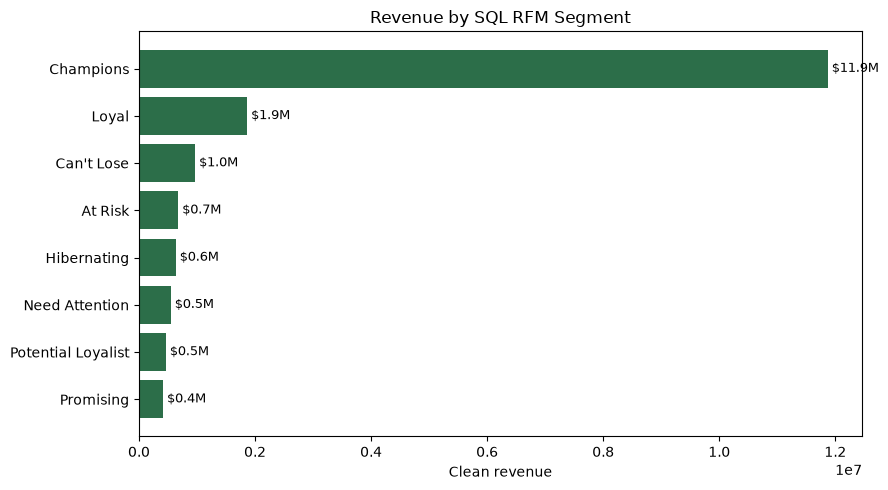

In [3]:
rfm = con.sql('SELECT * FROM rfm_segments').df()

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = segment_summary.sort_values('revenue', ascending=True)
ax.barh(plot_df['segment'], plot_df['revenue'], color='#2C6E49')
ax.set_title('Revenue by SQL RFM Segment')
ax.set_xlabel('Clean revenue')
for i, value in enumerate(plot_df['revenue']):
    ax.text(value, i, f' ${value/1_000_000:.1f}M', va='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'rfm_segment_revenue.png', dpi=160)
plt.show()


## K-Means diagnostic

K-Means is useful as a check on whether the RFM space has natural groupings, but the resulting cluster numbers are not stable marketing language. We test cluster counts 2 through 8 using inertia and silhouette score.

In [4]:
features = rfm[['days_since_last_order', 'frequency', 'monetary']]
scaled = StandardScaler().fit_transform(features)

rows = []
labels_by_k = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=25, random_state=20260921)
    labels = model.fit_predict(scaled)
    labels_by_k[k] = labels
    rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(scaled, labels),
    })

kmeans_diagnostics = pd.DataFrame(rows)
kmeans_diagnostics


/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/r

/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/tmp/retail-review-venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,k,inertia,silhouette
0,2,12091.406574,0.914062
1,3,7133.153970,0.578587
2,4,5204.991486,0.589733
3,5,3933.420230,0.599227
4,6,3291.407111,0.591980
5,7,2694.250435,0.547916
6,8,2205.270543,0.540129


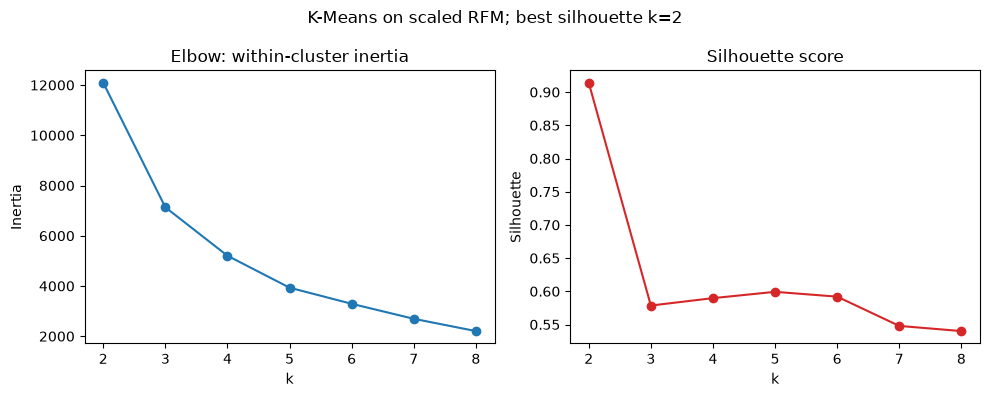

In [5]:
best_k = int(kmeans_diagnostics.loc[kmeans_diagnostics['silhouette'].idxmax(), 'k'])
rfm['kmeans_cluster'] = labels_by_k[best_k]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(kmeans_diagnostics['k'], kmeans_diagnostics['inertia'], marker='o', color='#1f77b4')
axes[0].set_title('Elbow: within-cluster inertia')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(kmeans_diagnostics['k'], kmeans_diagnostics['silhouette'], marker='o', color='#d62728')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
fig.suptitle(f'K-Means on scaled RFM; best silhouette k={best_k}')
fig.tight_layout()
fig.savefig(FIG_DIR / 'kmeans_rfm_diagnostics.png', dpi=160)
plt.show()


In [6]:
cluster_profile = (
    rfm.groupby('kmeans_cluster')
    .agg(
        customers=('customer_id', 'count'),
        avg_recency=('days_since_last_order', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        revenue=('monetary', 'sum'),
    )
    .round(2)
    .reset_index()
)
cluster_profile


,kmeans_cluster,customers,avg_recency,avg_frequency,avg_monetary,revenue
0,0,5829,200.44,5.73,2325.16,13553341.88
1,1,23,21.61,138.17,168744.47,3881122.85


In [7]:
pd.crosstab(rfm['segment'], rfm['kmeans_cluster'], normalize='index').round(2)


kmeans_cluster,0,1
segment,,
At Risk,1.00,0.00
Can't Lose,1.00,0.00
Champions,0.98,0.02
Hibernating,1.00,0.00
Loyal,1.00,0.00
Need Attention,1.00,0.00
Potential Loyalist,1.00,0.00
Promising,1.00,0.00


## Recommendation

Use the SQL RFM rules for the marketing activation list. K-Means is a useful analytical check, but the cluster labels are model-dependent, hard to explain, and can move when the customer file refreshes. The SQL rules map directly to CRM actions: reward Champions and Loyal customers, reactivate At Risk and Can't Lose customers, and suppress or low-cost nurture Hibernating customers.

In [8]:
print(f'best_k={best_k}')
print('top segment by revenue:', segment_summary.iloc[0]['segment'])
print(segment_summary[['segment', 'n_customers', 'revenue', 'revenue_pct']].to_string(index=False))


best_k=2
top segment by revenue: Champions
           segment  n_customers     revenue  revenue_pct
         Champions         1281 11869574.77         68.1
             Loyal          699  1863209.26         10.7
        Can't Lose          232   966514.03          5.5
           At Risk          599   676251.48          3.9
       Hibernating         1511   633618.41          3.6
    Need Attention          653   548030.99          3.1
Potential Loyalist          431   463069.74          2.7
         Promising          446   414196.05          2.4
